In [1]:
import os
import random
import joblib
import pickle
import pandas as pd
import numpy as np
import librosa
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import speech_recognition as sr
import cv2
import tensorflow as tf
from keras.models import Sequential, load_model, Model
from keras.layers import Conv1D, MaxPooling1D, Dense, Dropout, Activation, BatchNormalization, Flatten, SimpleRNN, LSTM, Conv2D, MaxPooling2D, Embedding, SpatialDropout1D, Reshape, Input
from keras.optimizers import Adam
from keras.utils import np_utils, to_categorical
from keras import regularizers
from keras.wrappers.scikit_learn import KerasClassifier
from keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from skimage import io, color, transform

# Loading Datasets #

## Test Dataset (Audio/Video) ##
This is the dataset that we created for testing the effectiveness of our audio/video models. There are **21 samples**, seven each from us attempting to portray an emotion. There are one of each emotion for each person, an an extra due to our system only taking into account **six basic emotions (happy, sad, disgust, anger, surprise, fear)**. We run a batch job to split the audio (.wav format) from the mp4 file using ffmpeg for audio and voice processing. A majority of the dataset (but not all) has us saying **"I lost a coin yesterday"** using different emotions, as a baseline for how the models are able process social signals from the voice and face even though we may be saying the same thing. Later on, we will test the text sentiment model with a separate dataset.

In [66]:
path_test_video = "Dataset/dataset.csv"
data_test_video = pd.read_csv(path_test_video)
data_test_video

,file,groundtruth
0,20240408_192255_disgust,disgust
1,20240408_192305_happy,happy
2,20240408_192310_sad,sad
3,20240408_192317_angry,angry
4,20240408_192343_fear,fear
5,20240408_192352_sad,sad
6,20240408_192608_surprise,surprise
7,20240409_134303_fear,fear
8,20240409_134326_disgust,disgust
9,20240409_134343_sad,sad


## Test Dataset (Text) ##
This is the dataset that we have created to test the effectiveness of our text sentiment analysis. The dataset contains a list of 20 sentences, labelled with a groundtruth. Just as a clarification, this is done separately from the Audio/Video models as if we said the same or similar things in the video, this model would be outputting the same results.

In [12]:
path_test_text = "Dataset/dataset_text.csv"
data_test_text = pd.read_csv(path_test_text)
data_test_text

,phrase,groundtruth
0,"The sun is shining, and the birds are singing....",happy
1,"I just got promoted at work, I'm over the moon!",happy
2,Seeing your smile brightens up my day.,happy
3,"It's been raining all day, I miss the sunshine.",sad
4,I feel a pang of sadness whenever I think of o...,sad
5,"The movie ended on a sad note, it left me feel...",sad
6,I can't stand the sight of litter in the park.,disgust
7,The smell of rotten eggs is revolting.,disgust
8,I felt a wave of disgust when I saw the cruelt...,disgust
9,Walking alone in the dark alley gave me the cr...,fear


## Ryerson Audio-Visual Database of Emotional Speech and Song (RAVDESS) Dataset ##
This is the dataset used for training the audio feature model. The RAVDESS dataset normally consistst of many features (speech, audio, video), however we are taking only the subset containing only audio (https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio).

In [41]:
audio_path = r"C:\Users\Keanu\Downloads\archive" # Path to where the RAVDESS audio files are stored

path = []
emotion = []
dataset = []

for foldername, _, filenames_in_folder in os.walk(audio_path):
    for name in filenames_in_folder:
        full_filename = os.path.join(foldername, name)
        info = name.replace(".wav", "").split("-")
        path.append(full_filename)
        emotion.append(int(info[2]))
        dataset.append("RAVDESS")

data_ravdess = pd.DataFrame({"path" : path, 
                             "emotion" : emotion,
                             "dataset" : dataset})

data_ravdess = data_ravdess[(data_ravdess['emotion'] != 1) & (data_ravdess['emotion'] != 2)]

def shiftEmotion(initial):
    return initial - 2

data_ravdess["emotion"] = data_ravdess["emotion"].apply(shiftEmotion)
data_ravdess

,path,emotion,dataset
12,C:\Users\Keanu\Downloads\archive\Actor_01\03-0...,1,RAVDESS
13,C:\Users\Keanu\Downloads\archive\Actor_01\03-0...,1,RAVDESS
14,C:\Users\Keanu\Downloads\archive\Actor_01\03-0...,1,RAVDESS
15,C:\Users\Keanu\Downloads\archive\Actor_01\03-0...,1,RAVDESS
16,C:\Users\Keanu\Downloads\archive\Actor_01\03-0...,1,RAVDESS
...,...,...,...
1435,C:\Users\Keanu\Downloads\archive\Actor_24\03-0...,6,RAVDESS
1436,C:\Users\Keanu\Downloads\archive\Actor_24\03-0...,6,RAVDESS
1437,C:\Users\Keanu\Downloads\archive\Actor_24\03-0...,6,RAVDESS
1438,C:\Users\Keanu\Downloads\archive\Actor_24\03-0...,6,RAVDESS


## GoEmotions Dataset ##
This is the dataset used for training the text sentiment model. The dataset consists of various comments from Reddit (https://github.com/google-research/google-research/tree/master/goemotions). It contains the following emotions: admiration, amusement, anger, annoyance, approval, caring, confusion, curiosity, desire, disappointment, disapproval, disgust, embarrassment, excitement, fear, gratitude, grief, joy, love, nervousness, optimism, pride, realization, relief, remorse, sadness, surprise. However we will be filtering them out to look for only the six basic emotions.

In [19]:
# Paths to the dataset files. They were split into multiple csv files.
datapaths = [r"C:\Users\Keanu\Downloads\data\full_dataset\goemotions_1.csv", r"C:\Users\Keanu\Downloads\data\full_dataset\goemotions_2.csv", r"C:\Users\Keanu\Downloads\data\full_dataset\goemotions_3.csv"]

dfs = []

for file in datapaths:
    df = pd.read_csv(file)
    dfs.append(df)

data_go = pd.concat(dfs, ignore_index=True)

emotions = ['anger', 'disgust', 'fear', 'joy', 'surprise', 'sadness']

data_go['emotion'] = None

for index, row in data_go.iterrows():
    for emotion in emotions:
        if row[emotion] == 1:
            data_go.at[index, 'emotion'] = emotion

data_go = data_go[data_go['emotion'].isin(emotions)]
data_go

,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id,example_very_unclear,admiration,...,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral,emotion
0,That game hurt.,eew5j0j,Brdd9,nrl,t3_ajis4z,t1_eew18eq,1.548381e+09,1,False,0,...,0,0,0,0,0,0,1,0,0,sadness
13,That is odd.,ee9vw9t,SoloTetherballChamp,jobs,t3_agy1as,t3_agy1as,1.547736e+09,50,False,0,...,0,0,0,0,0,0,0,0,0,disgust
29,So happy for [NAME]. So sad he's not here. Ima...,ee9zjio,YROK1986,DetroitPistons,t3_agty5q,t3_agty5q,1.547739e+09,15,False,0,...,0,0,0,0,0,0,1,0,0,sadness
32,"Dark and funny, but not really nice guy. He ha...",eerqrp7,porky2468,lostredditors,t3_aiy09d,t3_aiy09d,1.548257e+09,61,False,0,...,0,0,0,0,0,0,0,0,0,disgust
43,By far the coolest thing I've seen on this thr...,edm3k6w,W8nd3rW8man,popping,t3_ads2ve,t3_ads2ve,1.547009e+09,78,False,0,...,0,0,0,0,0,0,0,0,0,joy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211187,I just called the Capitol Police. They are not...,ee7fqma,Joyce_III,The_Donald,t3_agn1zp,t3_agn1zp,1.547660e+09,37,False,0,...,0,0,0,0,0,0,0,0,0,anger
211205,I just called the Capitol Police. They are not...,ee7fqma,Joyce_III,The_Donald,t3_agn1zp,t3_agn1zp,1.547660e+09,35,False,0,...,0,0,0,0,0,0,0,0,0,disgust
211212,What a great photo and you two look so happy. 😍,ee0sak1,Kevinc62,gaybros,t3_afpv2x,t3_afpv2x,1.547432e+09,27,False,1,...,0,0,0,0,0,0,0,0,0,joy
211219,"Well, I'm glad you're out of all that now. How...",ed89acy,pompompompi,raisedbynarcissists,t3_ac9etw,t1_ed7gt8x,1.546615e+09,2,False,0,...,0,0,0,0,0,0,0,0,0,joy


## Facial Emotion Recognition (FER2013) Dataset ##
We used the FER2013 dataset (https://www.kaggle.com/datasets/msambare/fer2013) training subset for training the image analysis model. It contains the six basic emotions along with the neutral emotion. Since we were only looking at the six basic emotions, we filtered out the neutral emotion. Initially, we ran this dataset through OpenFace to gather Action Units (AUs) from the images. This model however showed worse performance and so we opted for straight image analysis instead of AU analysis.

In [22]:
cols = [' AU01_r', ' AU02_r', ' AU04_r', ' AU05_r', ' AU06_r',
        ' AU07_r', ' AU09_r', ' AU10_r', ' AU12_r', ' AU14_r',
        ' AU15_r', ' AU17_r', ' AU20_r', ' AU23_r', ' AU25_r',
        ' AU26_r', ' AU45_r', ' AU01_c', ' AU02_c', ' AU04_c',
        ' AU05_c', ' AU06_c', ' AU07_c', ' AU09_c', ' AU10_c',
        ' AU12_c', ' AU14_c', ' AU15_c', ' AU17_c', ' AU20_c',
        ' AU23_c', ' AU25_c', ' AU26_c', ' AU28_c', ' AU45_c',
        'filename', 'emotion', 'dataset']

data_fer = pd.read_csv("fer2013_complete.csv", usecols=cols)

labels = {'happy': 0, 'sad': 1, 'angry': 2, 'fear': 3, 'disgust': 4, 'surprise': 5}

data_fer = data_fer[data_fer['dataset'] == 'test']
data_fer

,AU01_r,AU02_r,AU04_r,AU05_r,AU06_r,AU07_r,AU09_r,AU10_r,AU12_r,AU14_r,...,AU17_c,AU20_c,AU23_c,AU25_c,AU26_c,AU28_c,AU45_c,filename,emotion,dataset
0,0.00,0.00,0.00,0.74,0.25,0.00,0.00,0.00,0.00,0.00,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,PrivateTest_11296953.jpg,angry,test
1,0.06,0.00,0.00,0.79,0.13,0.00,0.00,0.13,0.00,0.00,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,PrivateTest_12403575.jpg,angry,test
2,0.00,0.21,0.00,0.10,0.02,0.00,0.88,0.00,0.00,0.14,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,PrivateTest_12766285.jpg,angry,test
3,0.00,0.36,0.45,1.08,0.00,0.00,0.00,0.00,0.00,0.00,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,PrivateTest_1290484.jpg,angry,test
4,0.62,0.40,0.00,1.30,0.00,0.00,0.00,0.00,0.00,0.00,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,PrivateTest_13463625.jpg,angry,test
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7834,0.82,0.31,0.00,1.53,0.00,0.55,0.00,0.00,0.00,0.00,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,PublicTest_97957698.jpg,surprise,test
7835,0.77,0.00,0.00,1.00,0.50,0.00,0.00,1.27,0.74,0.00,...,0.0,1.0,1.0,1.0,1.0,0.0,0.0,PublicTest_97995446.jpg,surprise,test
7836,0.16,0.00,0.00,0.86,0.00,0.00,0.00,0.00,0.00,0.00,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,PublicTest_98089595.jpg,surprise,test
7837,1.74,0.21,0.00,0.00,0.00,0.00,0.00,0.04,0.81,0.00,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,PublicTest_98972870.jpg,surprise,test


# Loading Models and Info #

## Audio Feature Model ##

In [31]:
model_audio = load_model("resources/model_audio.keras")
model_audio.summary()

Model: "sequential_55"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_68 (Conv1D)          (None, 58, 128)           512       
                                                                 
 max_pooling1d_67 (MaxPoolin  (None, 29, 128)          0         
 g1D)                                                            
                                                                 
 conv1d_69 (Conv1D)          (None, 27, 64)            24640     
                                                                 
 max_pooling1d_68 (MaxPoolin  (None, 13, 64)           0         
 g1D)                                                            
                                                                 
 lstm_35 (LSTM)              (None, 64)                33024     
                                                                 
 dense_136 (Dense)           (None, 256)             

## Text Sentiment Model (and Tokenizer) ##

In [70]:
with open('resources/tokenizer.pickle', 'rb') as handle:
    tokenizer = pickle.load(handle)
model_text = load_model("resources/model_text.keras")
model_text.summary()

Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_9 (Embedding)     (None, 250, 100)          5000000   
                                                                 
 spatial_dropout1d_7 (Spatia  (None, 250, 100)         0         
 lDropout1D)                                                     
                                                                 
 lstm_7 (LSTM)               (None, 100)               80400     
                                                                 
 dropout_2 (Dropout)         (None, 100)               0         
                                                                 
 dense_9 (Dense)             (None, 6)                 606       
                                                                 
Total params: 5,081,006
Trainable params: 5,081,006
Non-trainable params: 0
____________________________________________

## Image Analysis Model ##

In [30]:
model_image = load_model("resources/model_image.keras")
model_image.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 46, 46, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 23, 23, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 21, 21, 64)        18496     
                                                                 
 dropout (Dropout)           (None, 21, 21, 64)        0         
                                                                 
 conv2d_2 (Conv2D)           (None, 19, 19, 128)       73856     
                                                                 
 dropout_1 (Dropout)         (None, 19, 19, 128)       0         
                                                        

# Metrics for Audio Feature Model #

## RAVDESS Test Set ##

8/8 [==============================] - 0s 14ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.51      0.50        41
           1       0.57      0.62      0.59        34
           2       0.63      0.67      0.65        36
           3       0.68      0.47      0.56        40
           4       0.47      0.41      0.43        37
           5       0.55      0.67      0.60        43

    accuracy                           0.56       231
   macro avg       0.56      0.56      0.56       231
weighted avg       0.56      0.56      0.56       231

Confusion Matrix:


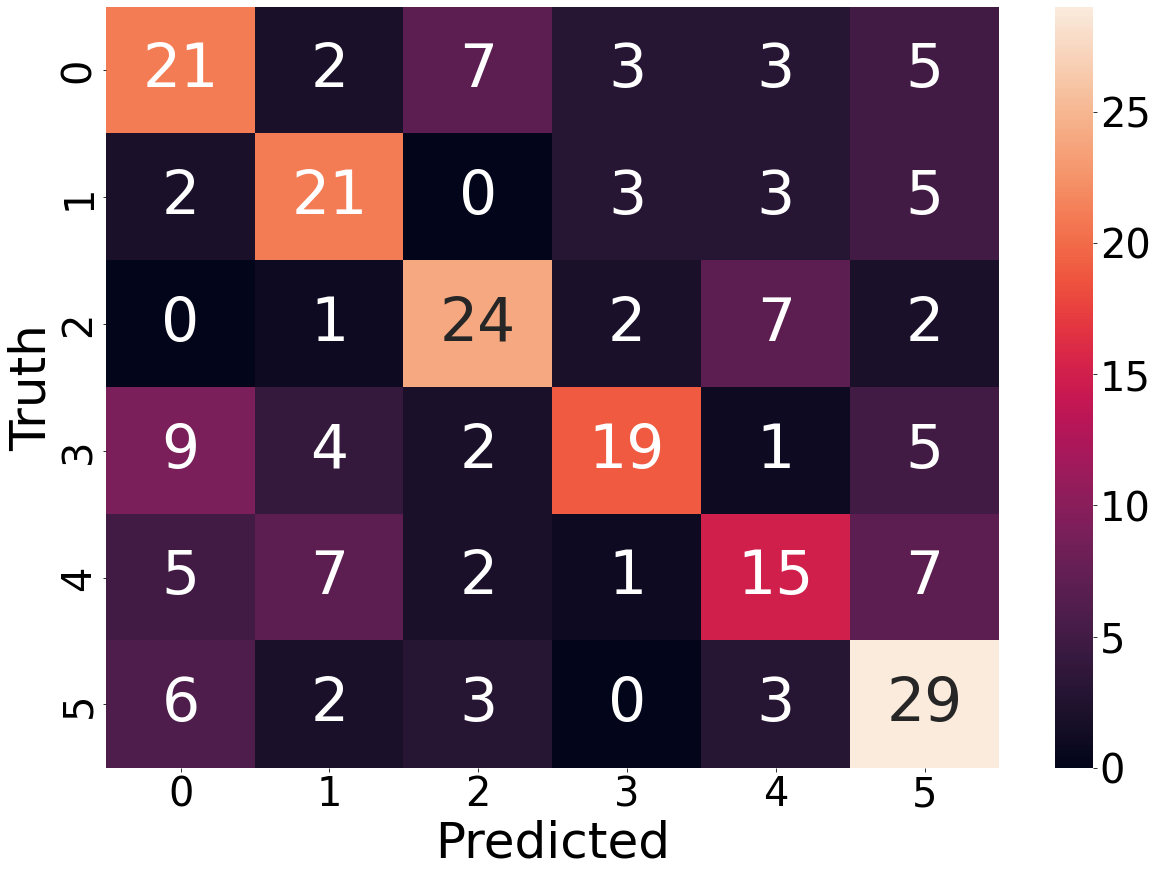

In [146]:
# Extract features from audio files
def extract_features(file_name):
    try:
        audio, sample_rate = librosa.load(file_name, res_type='kaiser_fast') 
        mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=60)
        mfccsscaled = np.mean(mfccs.T,axis=0)
        
    except Exception as e:
        print("Error encountered while parsing file: ", file_name)
        return None 
     
    return mfccsscaled

features = data_ravdess['path'].apply(extract_features)

# Convert features to array
features = np.array(features.tolist())

# Encode the labels
le = LabelEncoder()
y = le.fit_transform(data_ravdess['emotion'])

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(features, y, test_size=0.2, random_state=42)

# Reshape the features for CNN
X_train = np.expand_dims(X_train, axis=2)
X_test = np.expand_dims(X_test, axis=2)

y_pred = np.argmax(model_audio.predict(X_test), axis=1)

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(20,14))
heatmap = sns.heatmap(cm, annot=True, fmt='g', annot_kws={"size": 60})
plt.xlabel('Predicted', fontsize=50)
plt.ylabel('Truth', fontsize=50)
plt.xticks(fontsize=40)
plt.yticks(fontsize=40)
cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=40)
plt.show()

## Created Test Set ##

1/1 [==============================] - 0s 64ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.25      0.33      0.29         3
           1       0.00      0.00      0.00         3
           2       0.00      0.00      0.00         3
           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00         5
           5       0.00      0.00      0.00         4

    accuracy                           0.05        21
   macro avg       0.04      0.06      0.05        21
weighted avg       0.04      0.05      0.04        21

Confusion Matrix:


c:\users\keanu\appdata\local\programs\python\python39\lib\site-packages\sklearn\metrics\_classification.py:1327: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\users\keanu\appdata\local\programs\python\python39\lib\site-packages\sklearn\metrics\_classification.py:1327: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\users\keanu\appdata\local\programs\python\python39\lib\site-packages\sklearn\metrics\_classification.py:1327: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

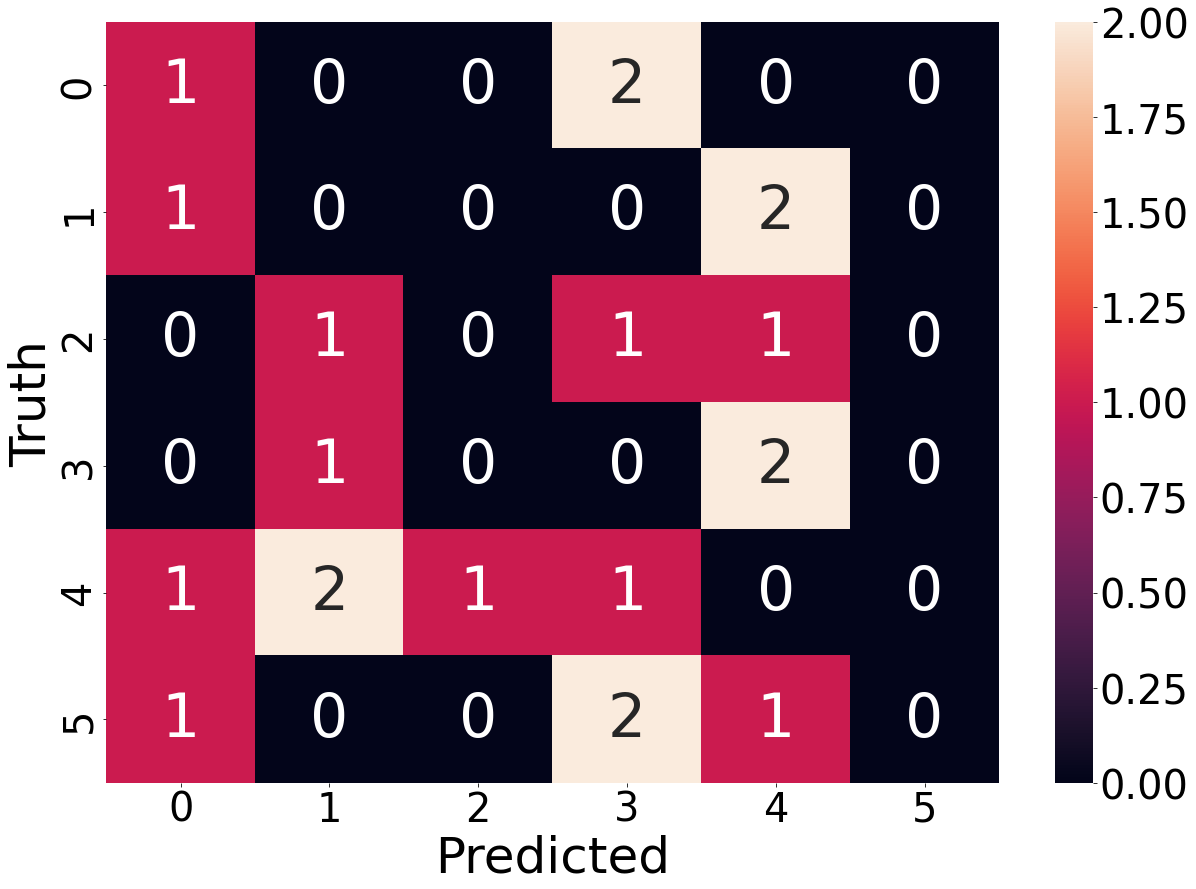

In [147]:
def extract_features2(file):
    return extract_features("Dataset/" + file + ".wav")

features = data_test_video['file'].apply(extract_features2)

# Convert features to array
features = np.array(features.tolist())

# Define the order of the classes
class_order = ['happy', 'sad', 'angry', 'fear', 'disgust', 'surprise']

# Initialize the label encoder
le = LabelEncoder()

# Set the classes in the label encoder
le.classes_ = np.array(class_order)

y = le.fit_transform(data_test_video['groundtruth'])

# Reshape the features for CNN
X_test = np.expand_dims(features, axis=2)

y_pred = np.argmax(model_audio.predict(X_test), axis=1)

print("Classification Report:")
print(classification_report(y, y_pred))

print("Confusion Matrix:")
cm = confusion_matrix(y, y_pred)
plt.figure(figsize=(20,14))
heatmap = sns.heatmap(cm, annot=True, fmt='g', annot_kws={"size": 60})
plt.xlabel('Predicted', fontsize=50)
plt.ylabel('Truth', fontsize=50)
plt.xticks(fontsize=40)
plt.yticks(fontsize=40)
cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=40)
plt.show()

# Metrics for Text Sentiment Model #

## GoEmotions Test Set ##

111/111 [==============================] - 1s 13ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.76      0.76       740
           1       0.68      0.66      0.67       681
           2       0.59      0.60      0.59       737
           3       0.62      0.59      0.60       304
           4       0.52      0.47      0.50       526
           5       0.60      0.69      0.65       552

    accuracy                           0.64      3540
   macro avg       0.63      0.63      0.63      3540
weighted avg       0.64      0.64      0.64      3540

Confusion Matrix:


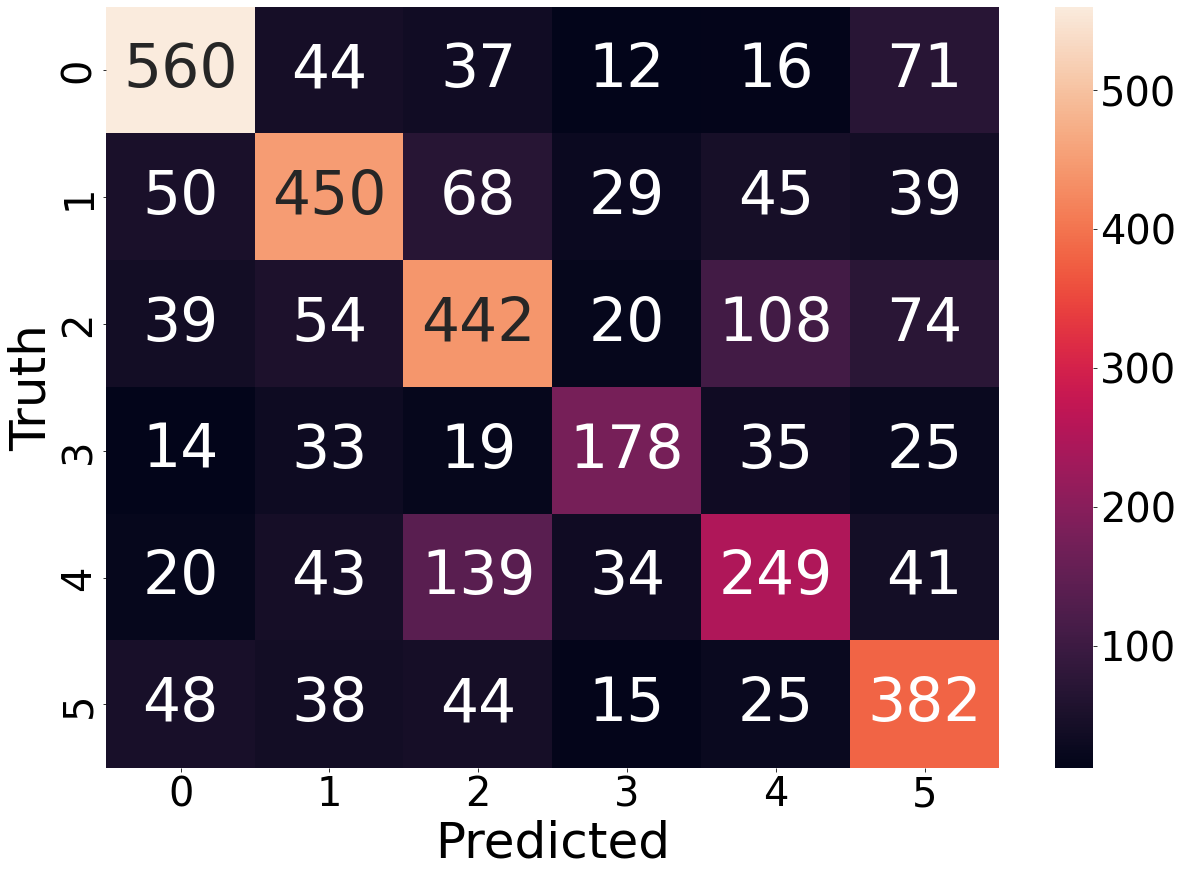

In [148]:
MAX_NB_WORDS = 50000
MAX_SEQUENCE_LENGTH = 250
EMBEDDING_DIM = 100

emotion_order = ['joy', 'sadness', 'anger', 'fear', 'disgust', 'surprise']

X = tokenizer.texts_to_sequences(data_go['text'].values)
X = pad_sequences(X, maxlen=MAX_SEQUENCE_LENGTH)

y = pd.get_dummies(data_go['emotion'])[emotion_order].values

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.10, random_state = 0)

y_pred = np.argmax(model_text.predict(X_test), axis=1)

print("Classification Report:")
print(classification_report(np.argmax(y_test, axis=1), y_pred))

print("Confusion Matrix:")
cm = confusion_matrix(np.argmax(y_test, axis=1), y_pred)
plt.figure(figsize=(20,14))
heatmap = sns.heatmap(cm, annot=True, fmt='g', annot_kws={"size": 60})
plt.xlabel('Predicted', fontsize=50)
plt.ylabel('Truth', fontsize=50)
plt.xticks(fontsize=40)
plt.yticks(fontsize=40)
cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=40)
plt.show()

## Created Test Set ##

1/1 [==============================] - 0s 93ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.75      0.60         4
           1       0.60      1.00      0.75         3
           2       1.00      0.50      0.67         4
           3       0.00      0.00      0.00         3
           4       1.00      1.00      1.00         3
           5       0.50      0.67      0.57         3

    accuracy                           0.65        20
   macro avg       0.60      0.65      0.60        20
weighted avg       0.61      0.65      0.60        20

Confusion Matrix:


c:\users\keanu\appdata\local\programs\python\python39\lib\site-packages\sklearn\metrics\_classification.py:1327: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\users\keanu\appdata\local\programs\python\python39\lib\site-packages\sklearn\metrics\_classification.py:1327: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\users\keanu\appdata\local\programs\python\python39\lib\site-packages\sklearn\metrics\_classification.py:1327: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

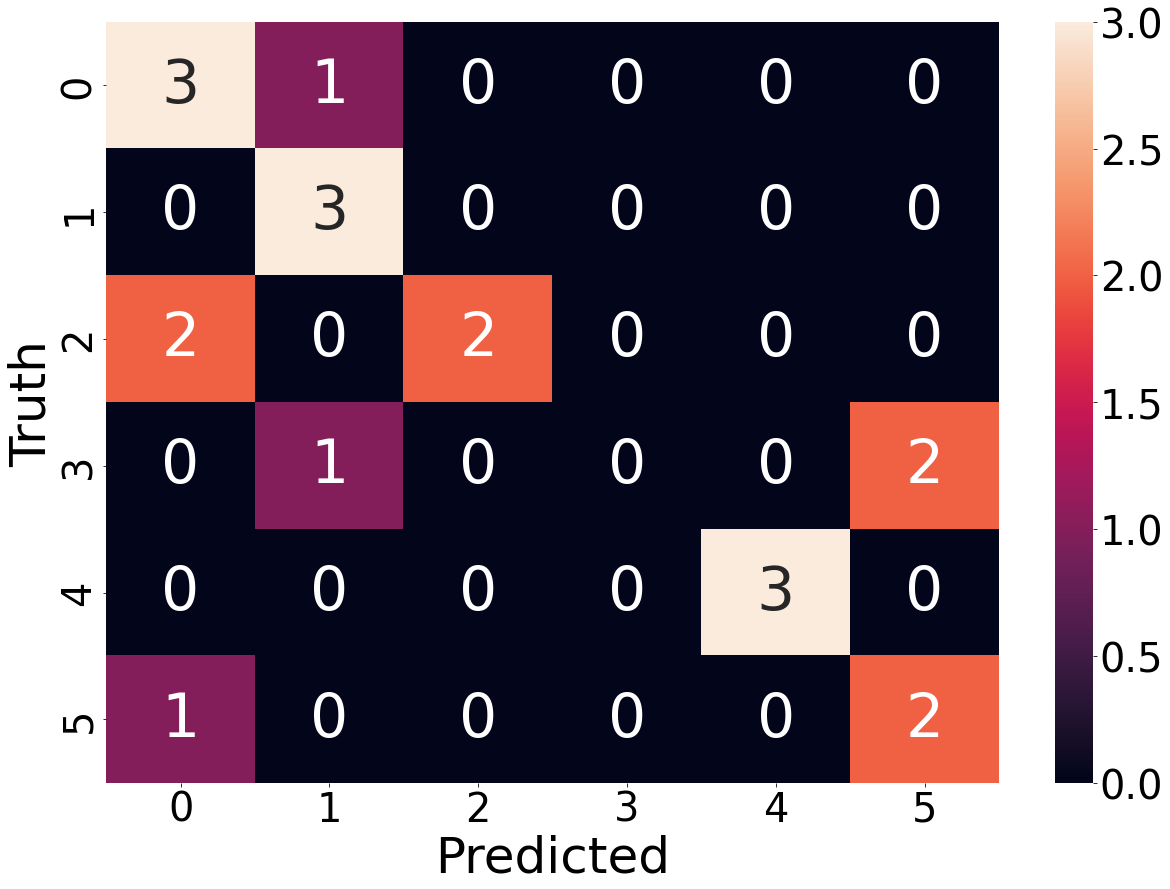

In [149]:
emotion_order = ['happy', 'sad', 'anger', 'fear', 'disgust', 'surprise']

X = tokenizer.texts_to_sequences(data_test_text['phrase'].values)
X = pad_sequences(X, maxlen=MAX_SEQUENCE_LENGTH)

y = pd.get_dummies(data_test_text['groundtruth'])[emotion_order].values

y_pred = np.argmax(model_text.predict(X), axis=1)

print("Classification Report:")
print(classification_report(np.argmax(y, axis=1), y_pred))

print("Confusion Matrix:")
cm = confusion_matrix(np.argmax(y, axis=1), y_pred)
plt.figure(figsize=(20,14))
heatmap = sns.heatmap(cm, annot=True, fmt='g', annot_kws={"size": 60})
plt.xlabel('Predicted', fontsize=50)
plt.ylabel('Truth', fontsize=50)
plt.xticks(fontsize=40)
plt.yticks(fontsize=40)
cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=40)
plt.show()

# Metrics for Image Analysis Model #

## FER2013 Test Set ##

56/56 [==============================] - 1s 9ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.88      0.83       495
           1       0.50      0.54      0.52       369
           2       0.43      0.48      0.46       276
           3       0.48      0.38      0.42       325
           4       0.86      0.45      0.59        66
           5       0.77      0.72      0.74       251

    accuracy                           0.62      1782
   macro avg       0.64      0.58      0.59      1782
weighted avg       0.62      0.62      0.61      1782

Confusion Matrix:


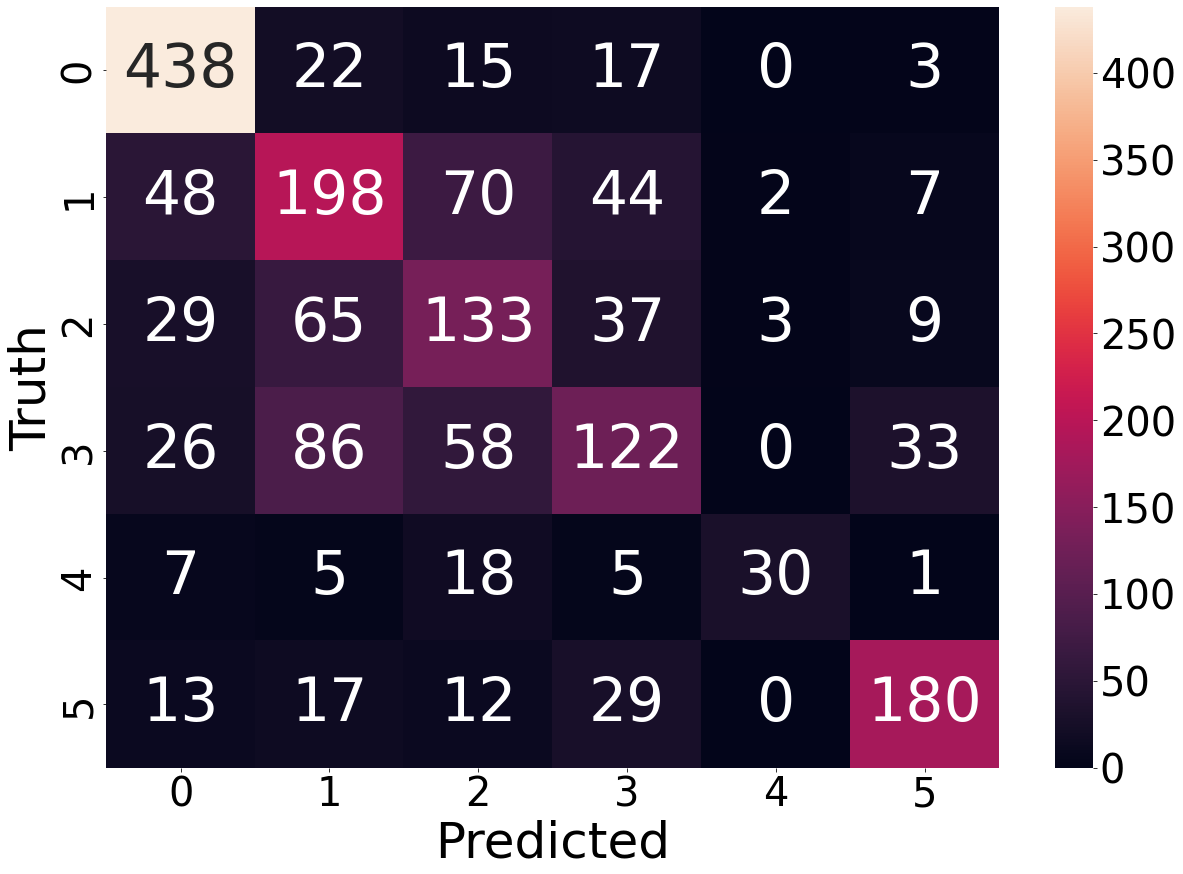

In [150]:
folder = r"C:\Users\Keanu\Downloads\fer2013/test"

test_images = []

for filename, emotion in zip(data_fer['filename'], data_fer['emotion']):
    label = os.path.join(folder, emotion)
    filepath = os.path.join(label, filename)
    if filepath.endswith('.jpg'):
        image = io.imread(filepath, as_gray=True)
        image_resized = transform.resize(image, (48, 48))
        image_reshaped = np.expand_dims(image_resized, axis=-1)
        test_images.append(image_reshaped)

X_test = np.array(test_images)
y_test = to_categorical(data_fer['emotion'].map(labels), num_classes = 6)

# get max of data
y_pred = np.argmax(model_image.predict(X_test), axis=1)

y_true = np.argmax(y_test, axis=1)

# classification report
print("Classification Report:")
print(classification_report(y_true, y_pred))

# confusion matrix
print("Confusion Matrix:")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(20,14))
heatmap = sns.heatmap(cm, annot=True, fmt='g', annot_kws={"size": 60})
plt.xlabel('Predicted', fontsize=50)
plt.ylabel('Truth', fontsize=50)
plt.xticks(fontsize=40)
plt.yticks(fontsize=40)
cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=40)
plt.show()

## Created Test Set ##

Classification Report:
              precision    recall  f1-score   support

           0       0.17      0.33      0.22         3
           1       1.00      0.20      0.33         5
           2       0.00      0.00      0.00         3
           3       0.08      0.33      0.12         3
           4       0.00      0.00      0.00         3
           5       0.00      0.00      0.00         4

    accuracy                           0.14        21
   macro avg       0.21      0.14      0.11        21
weighted avg       0.27      0.14      0.13        21

Confusion Matrix:


c:\users\keanu\appdata\local\programs\python\python39\lib\site-packages\sklearn\metrics\_classification.py:1327: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\users\keanu\appdata\local\programs\python\python39\lib\site-packages\sklearn\metrics\_classification.py:1327: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\users\keanu\appdata\local\programs\python\python39\lib\site-packages\sklearn\metrics\_classification.py:1327: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

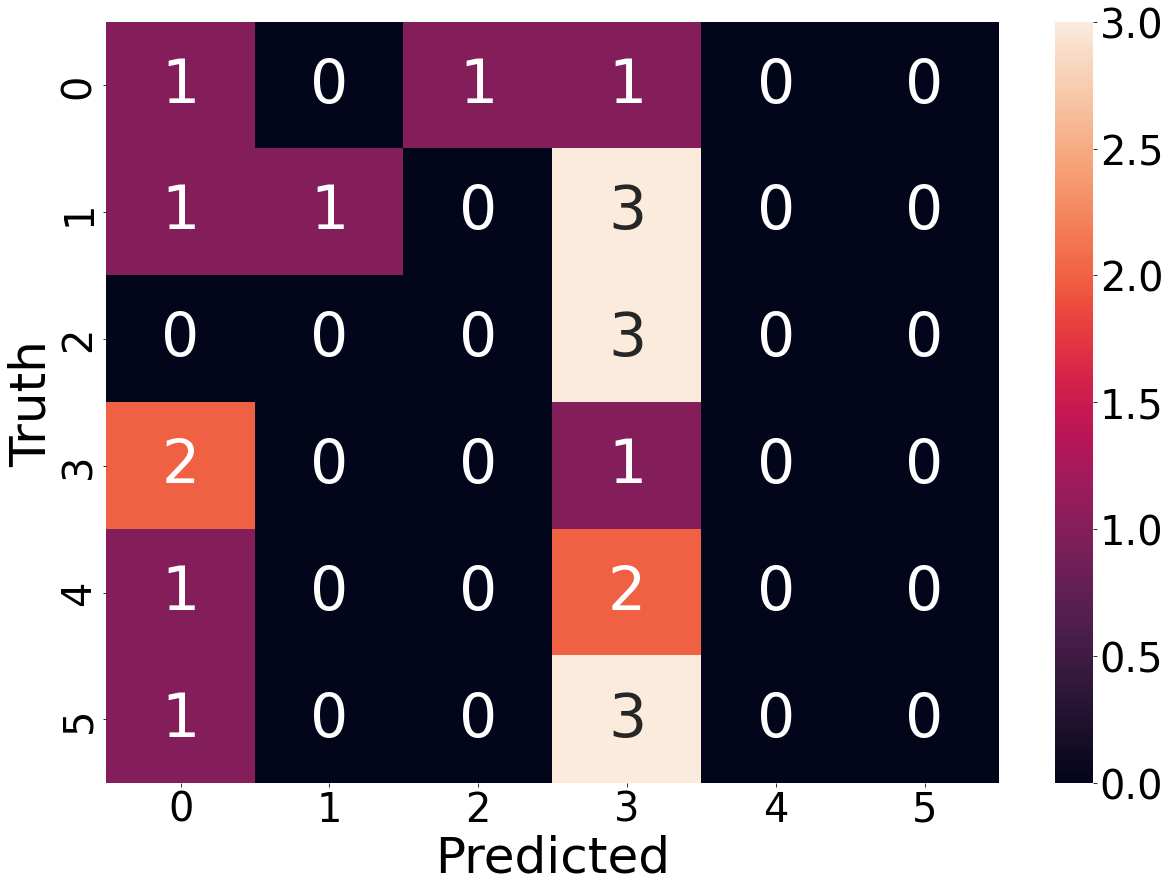

In [151]:
def image_combine(pred_arr):
    image_num = pred_arr.shape[0]
    summed = tf.reduce_sum(pred_arr, axis=0) / image_num
    return summed

def process_video(file):
    vid = cv2.VideoCapture(file)
    # Get the total number of frames in the video
    total_frames = int(vid.get(cv2.CAP_PROP_FRAME_COUNT))
    # Calculate the number of frames per second
    fps = int(vid.get(cv2.CAP_PROP_FPS))
    # Calculate the total number of seconds
    total_seconds = total_frames // fps

    # Array to hold the first frame of every second
    frames_every_second = []
    # For each second in the video
    for i in range(total_seconds):
        # Set the video position to the first frame of the current second
        vid.set(cv2.CAP_PROP_POS_FRAMES, i * fps)
        # Read the frame
        ret, frame = vid.read()
        if ret:
            # Crop the frame to 48x48 around the center
            y, x = frame.shape[0:2]
            start_x = x//2-(48//2)
            start_y = y//2-(48//2)
            cropped_frame = frame[start_y:start_y+48, start_x:start_x+48]
            # Add the cropped frame to the array
            frames_every_second.append(cropped_frame)

    frames_every_second = [cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY) for frame in frames_every_second]
    frames_every_second = [frame / 255.0 for frame in frames_every_second]
    frames_every_second = [np.expand_dims(frame, axis=2) for frame in frames_every_second]
    frames_every_second = np.array(frames_every_second)

    pred_arr_image = image_combine(model_image(frames_every_second))
    return pred_arr_image.numpy()


def predict_videos(file):
    return process_video("Dataset/" + file + ".mp4")
    
y_pred = data_test_video["file"].apply(predict_videos)

y_pred = np.argmax(np.vstack(y_pred.to_list()), axis=1)

emotion_mapping = {'happy': 0, 'sad': 1, 'angry': 2, 'fear': 3, 'disgust': 4, 'surprise': 5}

y_true = data_test_video["groundtruth"].replace(emotion_mapping).values

print("Classification Report:")
print(classification_report(y_true, y_pred))

# confusion matrix
print("Confusion Matrix:")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(20,14))
heatmap = sns.heatmap(cm, annot=True, fmt='g', annot_kws={"size": 60})
plt.xlabel('Predicted', fontsize=50)
plt.ylabel('Truth', fontsize=50)
plt.xticks(fontsize=40)
plt.yticks(fontsize=40)
cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=40)
plt.show()